In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 40 phyto (0.2–200 µm), 40 zoo (2–2000 µm)


In [3]:
# === Cell 1: setup — forcing, scan axes, binning machinery, obs target ===
import numpy as np, importlib
import cariaco_baseline_setups as cbs
import cariaco_obs as co
import parscan_utils as pu
import matplotlib.pyplot as plt
from xso.parscans import run_xso_parscan
for m in (cbs, co, pu): importlib.reload(m)

# Upwelling forcing (Inflow__FN, Inflow__de, Temperature__value) + R0-tuned overrides
_, _, bin_defs, monthly_up, forcing_up = co.load_cariaco_targets(
    'upwelling', months='hplc', agg='median', include_temperature=True)
N = cbs.N_CLASSES
fixed = {**forcing_up, 'Grazing__KsZ': np.full(N, 0.30), 'ZooLoss__rate': 0.3}

# Scan axes  (diatom_exp = -0.45 reproduces R0; > 0 = large cells grow faster)
EXP_VALS    = np.round(np.linspace(-0.45, 0.20, 14), 4)
THRESH_VALS = [5.0, 10.0, 20.0, 40.0]    # crossover ESD [µm], straddling Nano/Micro

# Binning (identical operator to the obs side)
phyto_esd = cbs.phyto_esd
W         = pu.phyto_bin_matrix(phyto_esd, bin_defs)        # (3, N): Pico/Nano/Micro
geomeans  = pu.CARIACO_PHYTO_BIN_GEOMEANS                   # [0.63, 6.3, 63.0]
TAIL      = 1000

# Obs upwelling target: per-month fractions -> median
pcols    = [b['column'] for b in bin_defs if b['type'] == 'phyto']
Pobs     = monthly_up[pcols].dropna().values
obs_frac = np.nanmedian(Pobs / Pobs.sum(axis=1, keepdims=True), axis=0)
obs_mcs  = np.nanmedian(10.0 ** ((Pobs / Pobs.sum(axis=1, keepdims=True)) @ np.log10(geomeans)))
print('obs upwelling  Pico/Nano/Micro =', np.round(obs_frac, 3), ' mcs =', round(obs_mcs, 2), 'µm')

obs upwelling  Pico/Nano/Micro = [0.448 0.224 0.313]  mcs = 4.84 µm


In [4]:
# === omni stabilization: sigma (kernel width) x m_Z at bloom F_N=8 ===
SIGMA_VALS = [0.10, 0.15, 0.20, 0.25]          # toward Mattern (~0.106 std equiv); 0.25 = current
MZ_VALS    = np.round(np.linspace(0.3, 1.2, 10), 3)
FN_TGT     = 8.0
fixed_sweep = {k: v for k, v in fixed.items() if k not in ('Inflow__FN', 'ZooLoss__rate')}  # de+temp+KsZ
fixed_sweep['Inflow__FN'] = FN_TGT

res_by_sigma = {}
for sg in SIGMA_VALS:
    phiPZ_sg = cbs.compute_grazing_kernel(cbs.phyto_esd, cbs.zoo_esd, 'omni',
                                          theta_opt=10.0, sigma_log=sg)
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T',
                          model_setup_name='model_setup_dist_omni_t3_T_slim',
                          param_name='ZooLoss__rate', param_values=MZ_VALS, processes=8,
                          fixed_overrides={**fixed_sweep, 'Grazing__phiPZ': phiPZ_sg})
    res_by_sigma[sg] = res

print(f"{'sigma':>6}{'m_Z':>6}{'Micro':>7}{'mcsP':>7}{'meanZ':>7}{'z95':>7}{'fZ>200':>8}{'ZoP':>7}{'CV':>8}")
for sg in SIGMA_VALS:
    res = res_by_sigma[sg]
    for k, mz in enumerate(MZ_VALS):
        P = res['Phytoplankton__biomass'].isel({'ZooLoss__rate': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'ZooLoss__rate': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any():
            print(f"{sg:6.2f}{mz:6.2f}{'  nan (crash)':>40}"); continue
        Pspec=P.mean(axis=1); sumP=Pspec.sum(); b=W@Pspec; f=b/b.sum()
        sP=P.sum(axis=0); cv=sP.std()/abs(sP.mean())
        Zs=Z.mean(axis=1); sumZ=Zs.sum(); zf=Zs/sumZ
        meanZ=10.0**(np.log10(zoo_esd)@zf); z95=zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95),len(zoo_esd)-1)]
        print(f"{sg:6.2f}{mz:6.2f}{f[2]:7.3f}{10.0**(np.log10(geomeans)@f):7.2f}"
              f"{meanZ:7.1f}{z95:7.0f}{Zs[zoo_esd>200].sum()/sumZ:8.3f}{sumZ/sumP:7.3f}{cv:8.4f}")
    print('-'*65)

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1324 on N = -2.65. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 32.4082 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=184.5 on P[8] = -0.00131. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: solve_ivp used 21656 RHS evaluations for 207 output points (105/output). The step controller is working hard — common causes are stiff dynamics or noise-floor tracking under tight atol. Consider switching to solver='stiff_ivp' (BDF + auto-derived sparse Jacobian; works well for stiff dissipative systems, may not for oscillatory predator-prey models), or loosening tolerances via solver_kwargs={'atol': 1e-6, 'rtol': 1e-4}. (This warning fires once per process.)
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub

1D Scan complete. Time taken: 123.412 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=36.31 on N = -4.4. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=54.62 on P[6] = -0.00103. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=85.21 on P[0] = -4.17. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instabili

1D Scan complete. Time taken: 153.7482 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 10 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=31.6 on P[0] = -0.0014. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=29.51 on P[6] = -0.00256. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=59.68 on P[0] = -0.0125. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'in

1D Scan complete. Time taken: 141.23236 seconds.
 sigma   m_Z  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.10  0.30                             nan (crash)
  0.10  0.40  0.237   3.23   13.1    118   0.025  0.621  0.0015
  0.10  0.50  0.222   3.22   11.3    118   0.016  0.566  0.0026
  0.10  0.60  0.106   2.48   10.4     98   0.000  0.530  0.0015
  0.10  0.70  0.023   2.10    9.4     82   0.000  0.493  0.0011
  0.10  0.80  0.000   2.12    8.4     69   0.000  0.454  0.0007
  0.10  0.90  0.000   2.09    8.1     69   0.000  0.439  0.0023
  0.10  1.00  0.000   2.09    7.6     48   0.000  0.415  0.0005
  0.10  1.10  0.000   2.11    7.1     48   0.000  0.392  0.0004
  0.10  1.20  0.000   2.05    7.0     48   0.000  0.382  0.0004
-----------------------------------------------------------------
  0.15  0.30                             nan (crash)
  0.15  0.40                             nan (crash)
  0.15  0.50  0.000   0.63   11.6    200   0.074  0.570  0.0004
  0.15  0.60  0.000   

In [5]:
# === omni at Mattern sigma: K_sZ x F_N, regime -> bloom (m_Z=0.3) ===
SIGMA_M   = 0.106                                   # = Mattern's 0.15 in the 2sigma^2 convention
KSZ_VALS  = [0.15, 0.20, 0.30, 0.45, 0.60, 0.80]    # Ward 0.15 / Dutkiewicz 0.23 ... up the stable side
FN_SET    = [round(forcing_up['Inflow__FN'], 2), 4.0, 6.0, 8.0]   # regime first
N         = cbs.N_CLASSES
phiPZ_M   = cbs.compute_grazing_kernel(cbs.phyto_esd, cbs.zoo_esd, 'omni', theta_opt=10.0, sigma_log=SIGMA_M)
fixed_kz  = {k: v for k, v in fixed.items() if k not in ('Inflow__FN', 'Grazing__KsZ')}  # de+temp+ZooLoss(0.3)

print(f"obs upwelling: Pico/Nano/Micro={np.round(obs_frac,3)}  mcs={obs_mcs:.2f} µm\n")
for fn in FN_SET:
    res = run_xso_parscan(model_file_name='cariaco_baseline_setups',
                          model_name='model_dist_t3_T', model_setup_name='model_setup_dist_omni_t3_T_slim',
                          param_name='Grazing__KsZ', param_values=[np.full(N, v) for v in KSZ_VALS],
                          processes=8,
                          fixed_overrides={**fixed_kz, 'Inflow__FN': fn, 'Grazing__phiPZ': phiPZ_M})
    print(f"=== F_N = {fn} ===")
    print(f"{'KsZ':>6}{'Micro':>7}{'mcsP':>7}{'meanZ':>7}{'z95':>7}{'fZ>200':>8}{'ZoP':>7}{'CV':>8}")
    for k, kz in enumerate(KSZ_VALS):
        P = res['Phytoplankton__biomass'].isel({'Grazing__KsZ': k}).values[:, -TAIL:]
        Z = res['Zooplankton__biomass'].isel({'Grazing__KsZ': k}).values[:, -TAIL:]
        if np.isnan(P).any() or np.isnan(Z).any():
            print(f"{kz:6.2f}{'   nan (crash)':>40}"); continue
        Pspec=P.mean(axis=1); sumP=Pspec.sum(); b=W@Pspec; f=b/b.sum()
        sP=P.sum(axis=0); cv=sP.std()/abs(sP.mean())
        Zs=Z.mean(axis=1); sumZ=Zs.sum(); zf=Zs/sumZ
        meanZ=10.0**(np.log10(zoo_esd)@zf); z95=zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95),len(zoo_esd)-1)]
        print(f"{kz:6.2f}{f[2]:7.3f}{10.0**(np.log10(geomeans)@f):7.2f}{meanZ:7.1f}"
              f"{z95:7.0f}{Zs[zoo_esd>200].sum()/sumZ:8.3f}{sumZ/sumP:7.3f}{cv:8.4f}")
    print('-'*55)

obs upwelling: Pico/Nano/Micro=[0.448 0.224 0.313]  mcs=4.84 µm

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 6 points using 8 workers...
1D Scan complete. Time taken: 70.75734 seconds.
=== F_N = 2.58 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15  0.184   1.66   20.5    285   0.114  1.185  0.0043
  0.20  0.000   0.70   14.4     98   0.039  1.393  0.0026
  0.30  0.000   0.63    9.2     34   0.022  1.437  0.0008
  0.45  0.000   0.63    6.4     20   0.000  1.259  0.0003
  0.60  0.000   0.63    5.0     20   0.000  0.975  0.0002
  0.80  0.000   0.63    3.8     20   0.000  0.879  0.0003
-------------------------------------------------------
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and se

/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=159 on P[0] = -3.63. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=416.9 on P[6] = -0.0465. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


1D Scan complete. Time taken: 65.91995 seconds.
=== F_N = 4.0 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15                             nan (crash)
  0.20                             nan (crash)
  0.30  0.000   0.83   11.5     98   0.008  1.184  0.0025
  0.45  0.000   0.71    7.4     20   0.000  1.236  0.0005
  0.60  0.000   0.63    5.7     20   0.000  1.142  0.0003
  0.80  0.000   0.63    4.3     20   0.000  0.929  0.0001
-------------------------------------------------------
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 6 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=71.13 on P[0] = -0.0107. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=164.5 on P[5] = -0.00101. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=153.7 on P[9] = -0.00197. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'

1D Scan complete. Time taken: 41.85588 seconds.
=== F_N = 6.0 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15                             nan (crash)
  0.20                             nan (crash)
  0.30                             nan (crash)
  0.45  0.000   1.04    8.8     41   0.000  0.976  0.0010
  0.60  0.000   0.89    6.7     20   0.000  1.003  0.0004
  0.80  0.000   0.76    4.9     20   0.000  0.960  0.0002
-------------------------------------------------------
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_dist_t3_T' and setup 'model_setup_dist_omni_t3_T_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 6 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=77.13 on P[0] = -0.00134. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=137.3 on P[4] = -0.00117. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=172 on N = -2.97. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instabi

1D Scan complete. Time taken: 35.50922 seconds.
=== F_N = 8.0 ===
   KsZ  Micro   mcsP  meanZ    z95  fZ>200    ZoP      CV
  0.15                             nan (crash)
  0.20                             nan (crash)
  0.30                             nan (crash)
  0.45  0.038   1.46   10.5     98   0.000  0.802  0.0015
  0.60  0.000   1.18    7.6     41   0.000  0.840  0.0005
  0.80  0.000   0.92    5.7     20   0.000  0.860  0.0003
-------------------------------------------------------


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=741.6 on P[0] = -0.00267. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


phyto Pico/Nano/Micro = [nan nan nan]  mcs=nanµm  (obs [0.448 0.224 0.313], mcs 4.84)
zoo  meanZ=nanµm  z95=2µm  fZ>200=nan  Z:P=nan


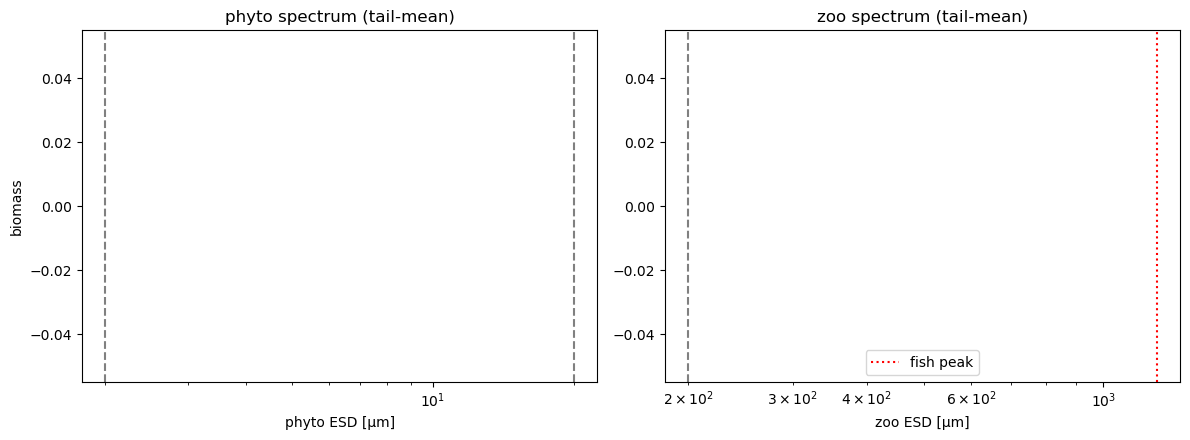

In [7]:
# === omni regime point: full spectra at K_sZ=0.15, F_N=regime, sigma=0.15(Mattern) ===
import matplotlib.pyplot as plt
N = cbs.N_CLASSES
out = pu.run_single_point(cbs.model_dist_t3_T, cbs.model_setup_dist_omni_t3_T_slim,
                          scan_params={'Grazing__KsZ': np.full(N, 0.15)},
                          fixed_overrides={**forcing_up, 'ZooLoss__rate': 0.3})
P = out['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1)
Z = out['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1)
phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd

b = W @ P; f = b/b.sum(); mcs = 10**(np.log10(geomeans)@f)
zf = Z/Z.sum(); meanZ = 10**(np.log10(zoo_esd)@zf)
z95 = zoo_esd[min(np.searchsorted(np.cumsum(zf),0.95), len(zoo_esd)-1)]
print(f"phyto Pico/Nano/Micro = {np.round(f,3)}  mcs={mcs:.2f}µm  (obs {np.round(obs_frac,3)}, mcs {obs_mcs:.2f})")
print(f"zoo  meanZ={meanZ:.1f}µm  z95={z95:.0f}µm  fZ>200={Z[zoo_esd>200].sum()/Z.sum():.3f}  Z:P={Z.sum()/P.sum():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(phyto_esd, P, marker='o', ms=3)
ax[0].axvline(2, ls='--', c='grey'); ax[0].axvline(20, ls='--', c='grey')
ax[0].set_xscale('log')   # size axis (3-decade) — log conventional for spectra; say if you want linear
ax[0].set_title('phyto spectrum (tail-mean)'); ax[0].set_xlabel('phyto ESD [µm]'); ax[0].set_ylabel('biomass')
ax[1].plot(zoo_esd, Z, marker='o', ms=3, color='C1')
ax[1].axvline(200, ls='--', c='grey'); ax[1].axvline(1230, ls=':', c='red', label='fish peak')
ax[1].set_xscale('log')
ax[1].set_title('zoo spectrum (tail-mean)'); ax[1].set_xlabel('zoo ESD [µm]'); ax[1].legend()
plt.tight_layout(); plt.show()